# ImageNet Transfer Learning

In [ ]:
import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_recall_fscore_support, roc_auc_score
from tensorflow.keras.preprocessing.image import load_img, img_to_array, smart_resize, ImageDataGenerator
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications import ResNet50, ResNet101, EfficientNetB0, VGG16
from tensorflow.keras.layers import Dense, Flatten, Dropout, BatchNormalization, RandomFlip, RandomRotation, RandomZoom, RandomContrast, RandomTranslation, Input, Activation, Lambda
from tensorflow.keras.regularizers import l2
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications.resnet import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_preprocess
from tensorflow.keras.applications.efficientnet import preprocess_input as efficientnet_preprocess

# Transfer Learning for Image Classification

*Data Exploration and Pre-processing*


In [ ]:
def load_image_dataset(folder_path):
    images = []
    labels = []

    for label_folder in os.listdir(folder_path):
        label_path = os.path.join(folder_path, label_folder)

        for file in os.listdir(label_path):
            image_path = os.path.join(label_path, file)
            image = load_img(image_path, target_size=(224,224))
            image_array = img_to_array(image)
            images.append(image_array)

            if 'buildings' in label_folder:
                labels.append(0)
            elif 'forest' in label_folder:
                labels.append(1)
            elif 'glacier' in label_folder:
                labels.append(2)
            elif 'mountain' in label_folder:
                labels.append(3)
            elif 'sea' in label_folder:
                labels.append(4)
            elif 'street' in label_folder:
                labels.append(5)

    return np.array(images), np.array(labels)


def display_random_images(images, labels):
    plt.figure(figsize=(10, 7))

    class_mapping = {0: 'Buildings', 1: 'Forest', 2: 'Glacier', 3: 'Mountain', 4: 'Sea', 5: 'Street'}

    unique_classes = np.unique(labels)
    random_indices = []
    for class_label in unique_classes:
        class_indices = np.where(labels == class_label)[0]
        random_indices.append(np.random.choice(class_indices))

    for i, idx in enumerate(random_indices):
        image = images[idx]
        label = class_mapping[labels[idx]]
        image_norm = image / 255.0

        plt.subplot(2, 3, i + 1)
        plt.imshow(image_norm)
        plt.axis('off')
        plt.title(f"{label}")
        plt.suptitle('Sample Image From Each Class')

    plt.subplots_adjust(wspace=0.4, hspace=0.4)
    plt.suptitle('Sample Image From Each Class', fontsize=16)
    plt.show()

In [ ]:
test_path = '../data/seg_test'
train_path = '../data/seg_train'

X_train, y_train = load_image_dataset(train_path)
X_test, y_test = load_image_dataset(test_path)

print('Train Set Size:', y_train.shape[0])
print('Test Set Size:', y_test.shape[0])

Train Set Size: 14042
Test Set Size: 3010


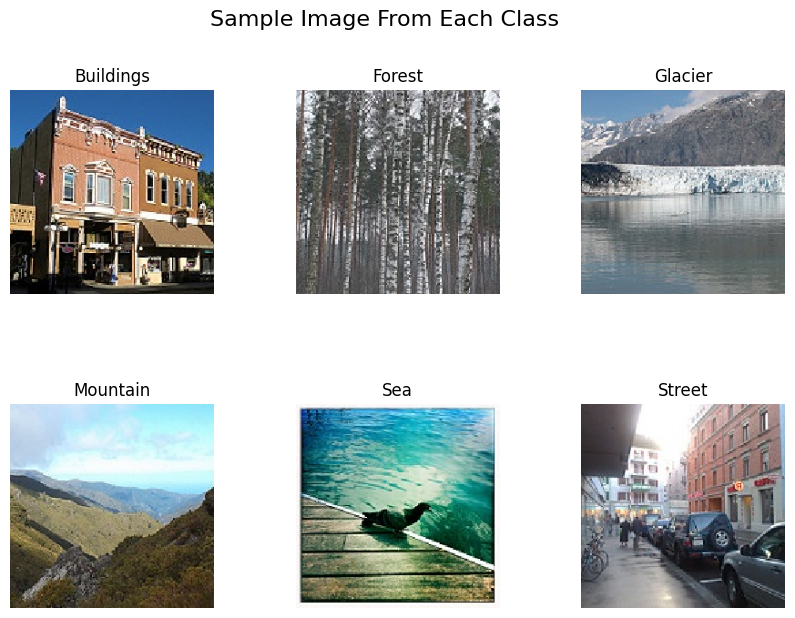

In [ ]:
display_random_images(X_test, y_test)

*Transfer Learning*

In [ ]:
X_subtrain, X_val, y_subtrain, y_val = train_test_split(X_train, y_train, test_size=0.2, stratify=y_train, random_state=24, shuffle=True)
y_subtrain_categorical = to_categorical(y_subtrain, num_classes=6)
y_val_categorical = to_categorical(y_val, num_classes=6)
y_test_categorical = to_categorical(y_test, num_classes=6)

In [ ]:
def build_model(pretrained_model, vgg=False):

    base_model = pretrained_model(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    for layer in base_model.layers:
        layer.trainable = False

    data_augmentation = Sequential([RandomFlip("horizontal_and_vertical"), RandomRotation(0.2), RandomZoom(0.1), RandomContrast(0.1), RandomTranslation(0.0, 0.1)])
    model = Sequential()
    model.add(Input(shape=(224,224,3)))
    model.add(data_augmentation)
    if vgg == True:
      model.add(Lambda(lambda x: vgg_preprocess(x*255.0)))
    model.add(base_model)
    model.add(Flatten())
    model.add(Dense(256, kernel_regularizer=l2(0.01)))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(Dropout(0.2))
    model.add(Dense(6, activation='softmax'))
    model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

    return model

In [ ]:
resnet50_model = build_model(ResNet50)
resnet101_model = build_model(ResNet101)
efficientnet_model = build_model(EfficientNetB0)
vgg16_model = build_model(VGG16, vgg=True)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
171446536/171446536 ━━━━━━━━━━━━━━━━━━━━ 8s 0us/step
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [ ]:
def plot_learning_curve(history):

    train_loss = history.history['loss']
    val_loss = history.history['val_loss']
    train_accuracy = history.history['accuracy']
    val_accuracy = history.history['val_accuracy']
    epochs = range(1, len(train_loss) + 1)

    fig, ax = plt.subplots(1,2, figsize=(12, 6))
    ax[0].plot(epochs, train_loss, label='Training Loss')
    ax[0].plot(epochs, val_loss, label='Validation Loss')
    ax[0].set_title('Training and Validation Loss')
    ax[0].set_xlabel('Epochs')
    ax[0].set_ylabel('Loss')
    ax[0].legend()

    ax[1].plot(epochs, train_accuracy, label='Training Accuracy')
    ax[1].plot(epochs, val_accuracy, label='Validation Accuracy')
    ax[1].set_title('Training and Validation Accuracy')
    ax[1].set_xlabel('Epochs')
    ax[1].set_ylabel('Accuracy')

    plt.show()

Epoch 1/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 31s 54ms/step - accuracy: 0.7145 - loss: 4.4056 - val_accuracy: 0.7700 - val_loss: 2.2806 - learning_rate: 0.0010
Epoch 2/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 13s 38ms/step - accuracy: 0.7563 - loss: 2.4537 - val_accuracy: 0.8060 - val_loss: 2.1162 - learning_rate: 0.0010
Epoch 3/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 13s 37ms/step - accuracy: 0.7417 - loss: 2.3257 - val_accuracy: 0.7868 - val_loss: 2.2119 - learning_rate: 0.0010
Epoch 4/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 13s 38ms/step - accuracy: 0.7492 - loss: 2.3030 - val_accuracy: 0.8131 - val_loss: 2.3253 - learning_rate: 0.0010
Epoch 5/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 13s 38ms/step - accuracy: 0.7523 - loss: 2.3408 - val_accuracy: 0.8138 - val_loss: 2.1200 - learning_rate: 0.0010
Epoch 6/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 13s 37ms/step - accuracy: 0.7552 - loss: 2.3347 - val_accuracy: 0.7455 - val_loss: 2.2677 - learning_rate: 0.0010
Epoch 7/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 13s 37ms/step - accuracy: 0.7

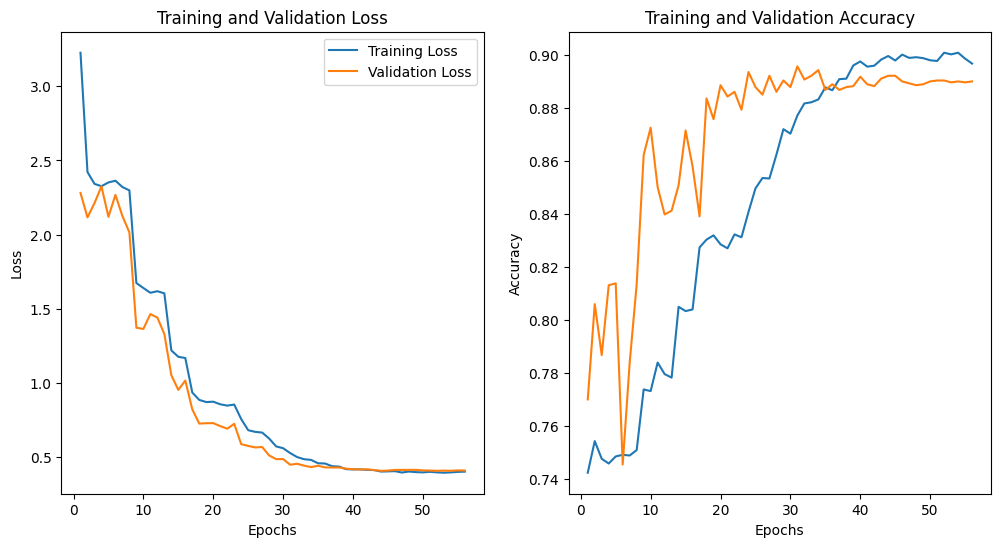

Best Training Accuracy: 0.900827944278717
Best Training Loss: 0.39660611748695374
Best Validation Accuracy: 0.8903524279594421
Best Validation Loss: 0.40683287382125854


In [ ]:
early_stopping_resnet50 = EarlyStopping(monitor='val_accuracy', patience=25, min_delta=1e-4, restore_best_weights=True)
lr_scheduler_resnet50 = ReduceLROnPlateau(monitor='val_accuracy', factor=0.5, patience=3, min_lr=1e-10)

X_subtrain_resnet = resnet_preprocess(X_subtrain)
X_val_resnet = resnet_preprocess(X_val)
X_test_resnet = resnet_preprocess(X_test)

resnet50_history = resnet50_model.fit(X_subtrain_resnet, y_subtrain_categorical, validation_data=(X_val_resnet, y_val_categorical), epochs=100, batch_size=32, verbose=1, callbacks=[early_stopping_resnet50, lr_scheduler_resnet50])
plot_learning_curve(resnet50_history)

best_epoch = np.argmin(resnet50_history.history['val_loss'])
best_train_accuracy = resnet50_history.history['accuracy'][best_epoch]
best_train_loss = resnet50_history.history['loss'][best_epoch]
best_val_accuracy = resnet50_history.history['val_accuracy'][best_epoch]
best_val_loss = resnet50_history.history['val_loss'][best_epoch]

print('Best Training Accuracy:', best_train_accuracy)
print('Best Training Loss:', best_train_loss)
print('Best Validation Accuracy:', best_val_accuracy)
print('Best Validation Loss:', best_val_loss)

Epoch 1/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 37s 71ms/step - accuracy: 0.7182 - loss: 4.4556 - val_accuracy: 0.8298 - val_loss: 2.3106 - learning_rate: 0.0010
Epoch 2/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 18s 52ms/step - accuracy: 0.7502 - loss: 2.4628 - val_accuracy: 0.7864 - val_loss: 2.3867 - learning_rate: 0.0010
Epoch 3/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 19s 53ms/step - accuracy: 0.7583 - loss: 2.4065 - val_accuracy: 0.8345 - val_loss: 2.2380 - learning_rate: 0.0010
Epoch 4/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 18s 52ms/step - accuracy: 0.7453 - loss: 2.3671 - val_accuracy: 0.7953 - val_loss: 2.1415 - learning_rate: 0.0010
Epoch 5/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 18s 51ms/step - accuracy: 0.7478 - loss: 2.3484 - val_accuracy: 0.8323 - val_loss: 1.9539 - learning_rate: 0.0010
Epoch 6/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 18s 51ms/step - accuracy: 0.7419 - loss: 2.3165 - val_accuracy: 0.8074 - val_loss: 2.2433 - learning_rate: 0.0010
Epoch 7/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 19s 53ms/step - accuracy: 0.7

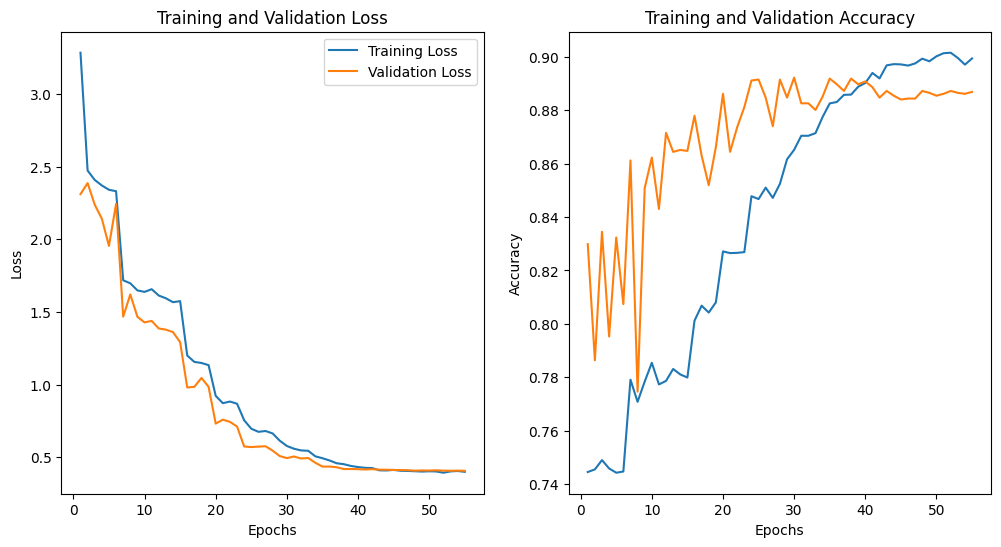

Best Training Accuracy: 0.8993145227432251
Best Training Loss: 0.39885392785072327
Best Validation Accuracy: 0.8867924809455872
Best Validation Loss: 0.40576350688934326


In [ ]:
early_stopping_resnet101 = EarlyStopping(monitor='val_accuracy', patience=25, min_delta=1e-4, restore_best_weights=True)
lr_scheduler_resnet101 = ReduceLROnPlateau(monitor='val_accuracy', factor=0.5, patience=3, min_lr=1e-10)

resnet101_history = resnet101_model.fit(X_subtrain_resnet, y_subtrain_categorical, validation_data=(X_val_resnet, y_val_categorical), epochs=100, batch_size=32, verbose=1, callbacks=[early_stopping_resnet101, lr_scheduler_resnet101])
plot_learning_curve(resnet101_history)

best_epoch = np.argmin(resnet101_history.history['val_loss'])
best_train_accuracy = resnet101_history.history['accuracy'][best_epoch]
best_train_loss = resnet101_history.history['loss'][best_epoch]
best_val_accuracy = resnet101_history.history['val_accuracy'][best_epoch]
best_val_loss = resnet101_history.history['val_loss'][best_epoch]

print('Best Training Accuracy:', best_train_accuracy)
print('Best Training Loss:', best_train_loss)
print('Best Validation Accuracy:', best_val_accuracy)
print('Best Validation Loss:', best_val_loss)

In [ ]:
early_stopping_efficientnet = EarlyStopping(monitor='val_accuracy', patience=25, min_delta=1e-4, restore_best_weights=True)
lr_scheduler_efficientnet = ReduceLROnPlateau(monitor='val_accuracy', factor=0.5, patience=3, min_lr=1e-10)

X_subtrain_efficientnet = efficientnet_preprocess(X_subtrain)
X_val_efficientnet = efficientnet_preprocess(X_val)
X_test_efficientnet = efficientnet_preprocess(X_test)

efficientnet_history = efficientnet_model.fit(X_subtrain_efficientnet, y_subtrain_categorical, validation_data=(X_val_efficientnet, y_val_categorical), epochs=100, batch_size=32, verbose=1, callbacks=[early_stopping_efficientnet, lr_scheduler_efficientnet])
plot_learning_curve(efficientnet_history)

best_epoch = np.argmin(efficientnet_history.history['val_loss'])
best_train_accuracy = efficientnet_history.history['accuracy'][best_epoch]
best_train_loss = efficientnet_history.history['loss'][best_epoch]
best_val_accuracy = efficientnet_history.history['val_accuracy'][best_epoch]
best_val_loss = efficientnet_history.history['val_loss'][best_epoch]

print('Best Training Accuracy:', best_train_accuracy)
print('Best Training Loss:', best_train_loss)
print('Best Validation Accuracy:', best_val_accuracy)
print('Best Validation Loss:', best_val_loss)

Epoch 1/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 19s 47ms/step - accuracy: 0.7063 - loss: 3.5406 - val_accuracy: 0.8295 - val_loss: 1.8968 - learning_rate: 0.0010
Epoch 2/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accuracy: 0.7627 - loss: 1.9345 - val_accuracy: 0.8320 - val_loss: 1.7605 - learning_rate: 0.0010
Epoch 3/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accuracy: 0.7577 - loss: 1.9050 - val_accuracy: 0.8352 - val_loss: 1.8264 - learning_rate: 0.0010
Epoch 4/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accuracy: 0.7665 - loss: 1.8600 - val_accuracy: 0.8405 - val_loss: 1.8349 - learning_rate: 0.0010
Epoch 5/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accuracy: 0.7516 - loss: 1.9101 - val_accuracy: 0.8416 - val_loss: 1.7235 - learning_rate: 0.0010
Epoch 6/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accuracy: 0.7572 - loss: 1.8644 - val_accuracy: 0.8309 - val_loss: 1.8209 - learning_rate: 0.0010
Epoch 7/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accuracy: 0.7

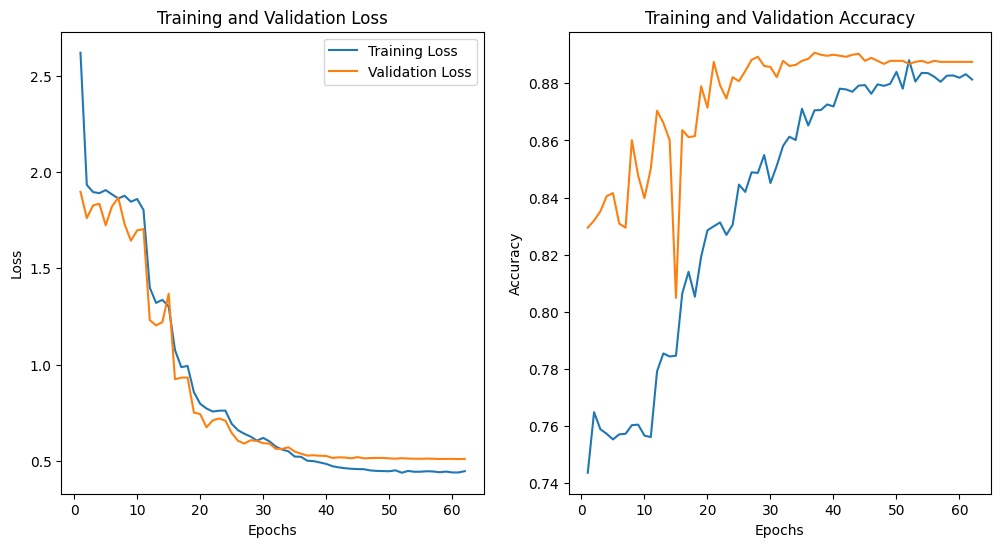

Best Training Accuracy: 0.8832013010978699
Best Training Loss: 0.44126614928245544
Best Validation Accuracy: 0.8875044584274292
Best Validation Loss: 0.5106341242790222


In [ ]:
early_stopping_vgg16 = EarlyStopping(monitor='val_accuracy', patience=25, min_delta=1e-4, restore_best_weights=True)
lr_scheduler_vgg16 = ReduceLROnPlateau(monitor='val_accuracy', factor=0.5, patience=3, min_lr=1e-10)

X_subtrain_norm = X_subtrain / 255.0
X_val_norm = X_val / 255.0
X_test_norm = X_test / 255.0

vgg16_history = vgg16_model.fit(X_subtrain_norm, y_subtrain_categorical, validation_data=(X_val_norm, y_val_categorical), epochs=100, batch_size=32, verbose=1, callbacks=[early_stopping_vgg16, lr_scheduler_vgg16])
plot_learning_curve(vgg16_history)

best_epoch = np.argmin(vgg16_history.history['val_loss'])
best_train_accuracy = vgg16_history.history['accuracy'][best_epoch]
best_train_loss = vgg16_history.history['loss'][best_epoch]
best_val_accuracy = vgg16_history.history['val_accuracy'][best_epoch]
best_val_loss = vgg16_history.history['val_loss'][best_epoch]

print('Best Training Accuracy:', best_train_accuracy)
print('Best Training Loss:', best_train_loss)
print('Best Validation Accuracy:', best_val_accuracy)
print('Best Validation Loss:', best_val_loss)

In [ ]:
def performance_metrics(model, X_subtrain, y_subtrain, X_val, y_val, X_test, y_test):
    y_train_pred_prob = model.predict(X_subtrain)
    y_train_pred = np.argmax(y_train_pred_prob, axis=1)
    train_accuracy = np.mean(y_subtrain == y_train_pred)
    train_precision, train_recall, train_f1, _ = precision_recall_fscore_support(y_subtrain, y_train_pred, average='weighted', zero_division=0)
    train_auc = roc_auc_score(y_subtrain_categorical, y_train_pred_prob, multi_class='ovr', average='weighted')

    y_val_pred_prob = model.predict(X_val)
    y_val_pred = np.argmax(y_val_pred_prob, axis=1)
    val_accuracy = np.mean(y_val == y_val_pred)
    val_precision, val_recall, val_f1, _ = precision_recall_fscore_support(y_val, y_val_pred, average='weighted', zero_division=0)
    val_auc = roc_auc_score(y_val_categorical, y_val_pred_prob, multi_class='ovr', average='weighted')

    y_test_pred_prob = model.predict(X_test)
    y_test_pred = np.argmax(y_test_pred_prob, axis=1)
    test_accuracy = np.mean(y_test == y_test_pred)
    test_precision, test_recall, test_f1, _ = precision_recall_fscore_support(y_test, y_test_pred, average='weighted', zero_division=0)
    test_auc = roc_auc_score(y_test_categorical, y_test_pred_prob, multi_class='ovr', average='weighted')

    return train_accuracy, train_recall, train_precision, train_f1, train_auc, val_accuracy, val_recall, val_precision, val_f1, val_auc, test_accuracy, test_recall, test_precision, test_f1, test_auc

In [ ]:
resnet50_metrics = performance_metrics(resnet50_model, X_subtrain_resnet, y_subtrain, X_val_resnet, y_val, X_test_resnet, y_test)
resnet101_metrics = performance_metrics(resnet101_model, X_subtrain_resnet, y_subtrain, X_val_resnet, y_val, X_test_resnet, y_test)
efficientnet_metrics = performance_metrics(efficientnet_model, X_subtrain_efficientnet, y_subtrain, X_val_efficientnet, y_val, X_test_efficientnet, y_test)
vgg16_metrics = performance_metrics(vgg16_model, X_subtrain_norm, y_subtrain, X_val_norm, y_val, X_test_norm, y_test)

results = {'Model': ['ResNet50', 'ResNet101', 'EfficientNetB0', 'VGG16'],
           'Training Accuracy': [resnet50_metrics[0], resnet101_metrics[0], efficientnet_metrics[0], vgg16_metrics[0]],
           'Training Recall': [resnet50_metrics[1], resnet101_metrics[1], efficientnet_metrics[1], vgg16_metrics[1]],
           'Training Precision': [resnet50_metrics[2], resnet101_metrics[2], efficientnet_metrics[2], vgg16_metrics[2]],
           'Training F1 Score': [resnet50_metrics[3], resnet101_metrics[3], efficientnet_metrics[3], vgg16_metrics[3]],
           'Training AUC Score': [resnet50_metrics[4], resnet101_metrics[4], efficientnet_metrics[4], vgg16_metrics[4]],
           'Validation Accuracy': [resnet50_metrics[5], resnet101_metrics[5], efficientnet_metrics[5], vgg16_metrics[5]],
           'Validation Recall': [resnet50_metrics[6], resnet101_metrics[6], efficientnet_metrics[6], vgg16_metrics[6]],
           'Validation Precision': [resnet50_metrics[7], resnet101_metrics[7], efficientnet_metrics[7], vgg16_metrics[7]],
           'Validation F1 Score': [resnet50_metrics[8], resnet101_metrics[8], efficientnet_metrics[8], vgg16_metrics[8]],
           'Validation AUC Score': [resnet50_metrics[9], resnet101_metrics[9], efficientnet_metrics[9], vgg16_metrics[9]],
           'Test Accuracy': [resnet50_metrics[10], resnet101_metrics[10], efficientnet_metrics[10], vgg16_metrics[10]],
           'Test Recall': [resnet50_metrics[11], resnet101_metrics[11], efficientnet_metrics[11], vgg16_metrics[11]],
           'Test Precision': [resnet50_metrics[12], resnet101_metrics[12], efficientnet_metrics[12], vgg16_metrics[12]],
           'Test F1 Score': [resnet50_metrics[13], resnet101_metrics[13], efficientnet_metrics[13], vgg16_metrics[13]],
           'Test AUC Score': [resnet50_metrics[14], resnet101_metrics[14], efficientnet_metrics[14], vgg16_metrics[14]]}

results_df = pd.DataFrame(results)
results_df.set_index('Model', inplace=True)
results_df

352/352 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step
352/352 ━━━━━━━━━━━━━━━━━━━━ 17s 39ms/step
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step
95/95 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step
352/352 ━━━━━━━━━━━━━━━━━━━━ 11s 23ms/step
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step
352/352 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step


,Training Accuracy,Training Recall,Training Precision,Training F1 Score,Training AUC Score,Validation Accuracy,Validation Recall,Validation Precision,Validation F1 Score,Validation AUC Score,Test Accuracy,Test Recall,Test Precision,Test F1 Score,Test AUC Score
Model,,,,,,,,,,,,,,,
ResNet50,0.914003,0.914003,0.913348,0.913104,0.991629,0.895692,0.895692,0.894320,0.894433,0.989156,0.893023,0.893023,0.891744,0.891761,0.988396
ResNet101,0.903054,0.903054,0.902561,0.901966,0.990577,0.892132,0.892132,0.891206,0.890882,0.988032,0.896013,0.896013,0.894956,0.894695,0.988269
EfficientNetB0,0.895041,0.895041,0.895844,0.893674,0.989713,0.877180,0.877180,0.877169,0.875284,0.985607,0.874751,0.874751,0.875390,0.872715,0.984495
VGG16,0.900472,0.900472,0.902425,0.899935,0.988603,0.890708,0.890708,0.894009,0.890095,0.986622,0.884718,0.884718,0.887216,0.884246,0.985700


We can see from the results above that all four models perform well with testing accuracies of around 90%. There does not seem to be one model that performs significantly better then all of the others. However, ResNet101 seems to be the best performing model on most metrics by a very slight margin.